In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [5]:
#LSE Algorithms

In [6]:
try:
    # Read the file in chunks of 10,000 rows at a time
    chunks = pd.read_csv('ecommerce1.csv', chunksize=10000)
    
    # Process each chunk (example: combine them all)
    df = pd.concat(chunks)
    
    # Or process each chunk individually
    # for chunk in chunks:
    #     process(chunk)
except Exception as e:
    print(f"Error: {e}")

In [7]:
df = pd.read_csv('ecommerce1.csv')

In [8]:
df

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620145
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510


In [9]:
#Exloratory Data Analysis

In [10]:
df.rename(columns = {'Avg. Session Length' : 'ASL', 'Time on App': 'ToA', 'Length of Membership' : 'LoM', 'Yearly Amount Spent':'YAS'}, inplace = True)

In [11]:
df1 = df

In [12]:
df1['interceft'] = [1] * 500

In [13]:
X1 = df1[['interceft','ASL', 'ToA', 'Time on Website', 'LoM']]

In [14]:
X1

,interceft,ASL,ToA,Time on Website,LoM
0,1,34.497268,12.655651,39.577668,4.082621
1,1,31.926272,11.109461,37.268959,2.664034
2,1,33.000915,11.330278,37.110597,4.104543
3,1,34.305557,13.717514,36.721283,3.120179
4,1,33.330673,12.795189,37.536653,4.446308
...,...,...,...,...,...
495,1,33.237660,13.566160,36.417985,3.746573
496,1,34.702529,11.695736,37.190268,3.576526
497,1,32.646777,11.499409,38.332576,4.958264
498,1,33.322501,12.391423,36.840086,2.336485


In [15]:
y1 = df1['YAS']

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, x_test, y_train, y_test = train_test_split(X1, y1, test_size = 0.3, random_state = 0)

In [18]:
Theta = np.linalg.inv((X_train.T) @ X_train)@(X_train.T)@y_train

In [19]:
Theta

0   -1037.825749
1      25.767530
2      38.800394
3      -0.018041
4      61.852568
dtype: float64

In [20]:
Theta = np.array(Theta)

In [21]:
def predict(X_test):
    return X_test @ Theta

In [22]:
y_pred = predict(x_test)

In [23]:
y_pred

90     438.053618
254    489.885692
283    370.691035
445    514.760391
461    496.718922
          ...    
4      591.820087
318    573.233331
331    524.023929
245    395.157380
5      640.762194
Length: 150, dtype: float64

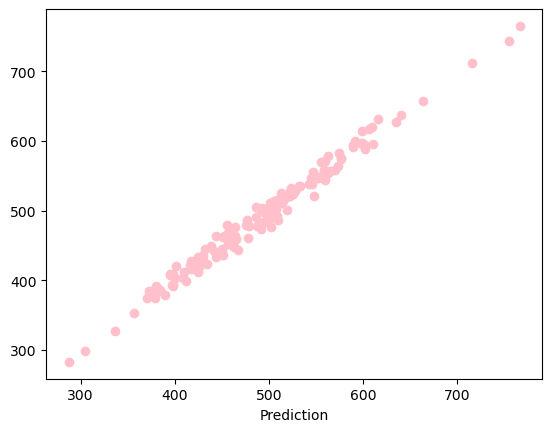

In [24]:
plt.scatter(y_pred, y_test, color = 'pink')
plt.xlabel('Prediction')
plt.show()

In [25]:
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE

In [26]:
print("Mean Square Error: ", MSE(y_pred, y_test))

Mean Square Error:  94.55779479272736


In [27]:
# Multiple Gradient Descent

In [28]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [30]:
df2 = pd.read_csv('ecommerce1.csv')

In [31]:
data = df2

In [32]:
data = data[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]

In [ ]:
data

In [33]:
data['b'] = [1] * 500

/var/folders/t5/jz1k7wm91wg21d8k4tm8nzp80000gn/T/ipykernel_1191/3846942293.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['b'] = [1] * 500


In [108]:
X_new = np.array(data)

In [109]:
y = np.array(df2['Yearly Amount Spent']).reshape(-1, 1)

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X_train, x_test, y_train, y_test = train_test_split(X_new, y, test_size = 0.3, random_state = 0)

In [112]:
w = [5.0] * 5

In [113]:
w = np.array(w).reshape(-1,1)

In [114]:
erochs = 10000000
n = len(y)
for i in range(erochs):
    error = y_train - X_train@w
    grad = -(2/n)* (X_train.T) @ error 
    w -= 0.0001 * grad
print(w)

[[  16.53155608]
 [  36.09662639]
 [  -8.2272122 ]
 [  61.64795005]
 [-394.80020159]]


In [115]:
y_pred = x_test @ w

In [116]:
y_pred = np.array(y_pred)

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Predictions')

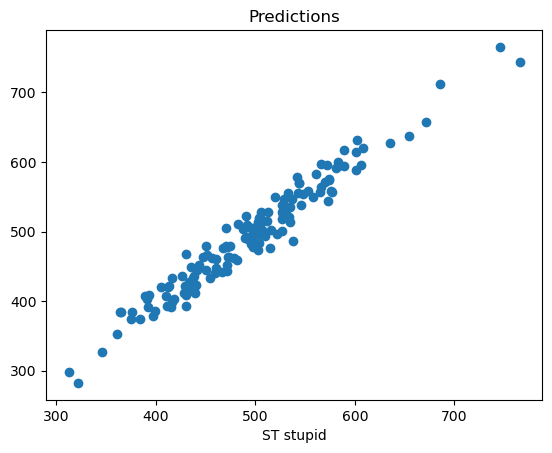

In [119]:
plt.scatter(x = y_pred,y = y_test)
plt.xlabel('ST stupid')
plt.title('Predictions')

In [121]:
residual = y_test - y_pred

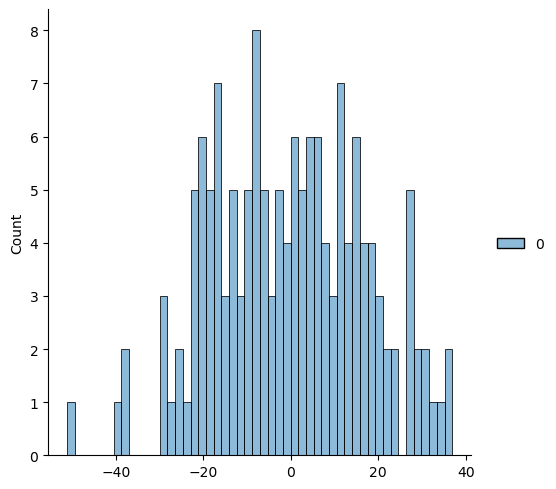

In [123]:
sns.displot(residual, bins = 50)